In [11]:
import pandas as pd
import datetime as dt
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
import importlib

from functools import reduce

from functions import (
    month_calendar,
    MAU,
    new_user_d7_retention,
    new_user_d30_retention,
    monthly_retention,
    total_number_of_actions,
    number_of_posts_discussions,
    user_churn,
    percentage_new_users_receiving_first_reply,
    median_time_to_first_reply,
    median_time_to_be_answered,
    unanswered_rate,
    average_replies_per_topic,
    number_of_regular_users,
    core_contribution_share,
    reactivated_users_count,
    add_mom_yoy,
    resolution_rate,
    answered_but_unresolved_rate,
    new_user_activation_rate,
    stickiness,
    newcomer_response_metrics_fast,
    average_thread_messages,
)

import warnings
warnings.filterwarnings("ignore")

sns.set(style="darkgrid")
import warnings

In [12]:
ds_chats = {}
folder_path = r'..\data\raw_data'
csv_files = glob.glob(os.path.join(folder_path, '*.csv'))

skip_col = ['post_type', 'parent_id', 'is_accepted_answer']

for file_path in csv_files:
    # Получаем имя файла без расширения
    filename = os.path.splitext(os.path.basename(file_path))[0]
    
    # Читаем CSV
    ds_chats[filename] = pd.read_csv(file_path)

for name, data in ds_chats.items():
    data.drop(data[data['author_id'] < 0].index, inplace=True)
    data['created_at'] = pd.to_datetime(data['created_at'], format='mixed', errors='coerce')

In [13]:
len(list(ds_chats))

36

In [14]:
metric_funcs = [
    month_calendar,
    MAU,
    new_user_d7_retention,
    new_user_d30_retention,
    monthly_retention,
    total_number_of_actions,
    number_of_posts_discussions,
    user_churn,
    percentage_new_users_receiving_first_reply,
    median_time_to_first_reply,
    median_time_to_be_answered,
    unanswered_rate,
    average_replies_per_topic,
    number_of_regular_users,
    core_contribution_share,
    reactivated_users_count,
    resolution_rate,
    answered_but_unresolved_rate,
    new_user_activation_rate,
    stickiness,
    newcomer_response_metrics_fast,
    average_thread_messages,
]

pivots_table = {}

for name, data in ds_chats.items():

    tables = [func(data) for func in metric_funcs]

    table = reduce(
        lambda left, right: left.merge(right, on='month', how='outer'),
        tables
    )

    table = table.sort_values('month').reset_index(drop=True)

    metric_columns = [col for col in table.columns if col != 'month']

    mom_yoy_tables = [
    add_mom_yoy(table[['month', col]].copy(), metric_column=col)
    for col in metric_columns
    ]

    final_table = reduce(
        lambda left, right: left.merge(right, on='month', how='outer'),
        mom_yoy_tables
    )

    pivots_table[name] = final_table.sort_values('month').reset_index(drop=True)

In [15]:
pd.to_pickle(pivots_table, r"model/pivots_table.pkl")

In [16]:
pivots_table = pd.read_pickle("model/pivots_table.pkl")

In [17]:
pivots_table['elastic'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176 entries, 0 to 175
Data columns (total 70 columns):
 #   Column                                              Non-Null Count  Dtype    
---  ------                                              --------------  -----    
 0   month                                               176 non-null    period[M]
 1   mau                                                 168 non-null    float64  
 2   mau_mom                                             162 non-null    float64  
 3   mau_yoy                                             153 non-null    float64  
 4   d7                                                  167 non-null    float64  
 5   d7_mom                                              161 non-null    float64  
 6   d7_yoy                                              151 non-null    float64  
 7   d30                                                 167 non-null    float64  
 8   d30_mom                                             161 non-

In [18]:
pivots_table['acer'].head(10)

,month,mau,mau_mom,mau_yoy,d7,d7_mom,d7_yoy,d30,d30_mom,d30_yoy,...,newcomer_no_response_rate_1h_yoy,newcomer_median_time_to_first_response_minutes,newcomer_median_time_to_first_response_minutes_mom,newcomer_median_time_to_first_response_minutes_yoy,newcomer_first_day_response_rate,newcomer_first_day_response_rate_mom,newcomer_first_day_response_rate_yoy,average_thread_messages,average_thread_messages_mom,average_thread_messages_yoy
0,2006-08,607.0,NaN,NaN,6.425041,NaN,NaN,3.953871,NaN,NaN,...,NaN,5.533333,NaN,NaN,100.0,NaN,NaN,5.918280,NaN,NaN
1,2006-09,954.0,57.166392,NaN,6.930693,7.870018,NaN,3.836634,-2.965140,NaN,...,NaN,3.091667,-44.126506,NaN,100.0,0.0,NaN,5.909831,-0.142762,NaN
2,2006-10,1053.0,10.377358,NaN,6.632653,-4.300292,NaN,3.061224,-20.210665,NaN,...,NaN,1.266667,-59.029650,NaN,100.0,0.0,NaN,7.816166,32.257030,NaN
3,2006-11,1214.0,15.289649,NaN,8.210784,23.793363,NaN,2.818627,-7.924837,NaN,...,NaN,1.300000,2.631579,NaN,100.0,0.0,NaN,8.854008,13.278138,NaN
4,2006-12,1083.0,-10.790774,NaN,8.153846,-0.693456,NaN,5.076923,80.120401,NaN,...,NaN,1.416667,8.974359,NaN,100.0,0.0,NaN,9.264674,4.638197,NaN
5,2007-01,1449.0,33.795014,NaN,7.660021,-6.056346,NaN,5.456453,7.475595,NaN,...,NaN,0.716667,-49.411765,NaN,100.0,0.0,NaN,11.243481,21.358631,NaN
6,2007-02,1705.0,17.667357,NaN,10.560748,37.868391,NaN,5.607477,2.767793,NaN,...,NaN,0.583333,-18.604651,NaN,100.0,0.0,NaN,12.298697,9.385132,NaN
7,2007-03,1535.0,-9.970674,NaN,11.256545,6.588519,NaN,6.675393,19.044503,NaN,...,NaN,0.475000,-18.571429,NaN,100.0,0.0,NaN,15.385816,25.101184,NaN
8,2007-04,1497.0,-2.475570,NaN,8.297568,-26.286722,NaN,3.147353,-52.851412,NaN,...,NaN,0.483333,1.754386,NaN,100.0,0.0,NaN,15.842123,2.965767,NaN
9,2007-05,1568.0,4.742819,NaN,6.914894,-16.663610,NaN,3.723404,18.302708,NaN,...,NaN,0.600000,24.137931,NaN,100.0,0.0,NaN,12.908354,-18.518788,NaN


In [19]:
qa_chat_check = []

for name, data in ds_chats.items():
    df = data.copy()

    rows = len(df)
    topics = df['topic_id'].nunique() if 'topic_id' in df.columns else np.nan
    users = df['author_id'].nunique() if 'author_id' in df.columns else np.nan

    accepted_mask = (
        df['is_accepted_answer']
        .fillna(False)
        .astype(str)
        .str.lower()
        .isin(['true', '1', '1.0', 'yes'])
    )

    accepted_posts = accepted_mask.sum()
    accepted_topics = df.loc[accepted_mask, 'topic_id'].nunique()

    accepted_topic_pct = (
        accepted_topics / topics * 100
        if topics and topics > 0
        else 0
    )

    reply_time_pct = (
        df['reply_time'].notna().mean() * 100
        if 'reply_time' in df.columns
        else 0
    )

    parent_pct = (
        df['parent_id'].notna().mean() * 100
        if 'parent_id' in df.columns
        else 0
    )

    topic_lengths = df.groupby('topic_id').size()

    avg_msgs_per_topic = topic_lengths.mean()
    median_msgs_per_topic = topic_lengths.median()
    p90_msgs_per_topic = topic_lengths.quantile(0.9)
    single_msg_topic_pct = (topic_lengths == 1).mean() * 100

    post_type_dist = (
        df['post_type']
        .value_counts(normalize=True, dropna=False)
        .mul(100)
        .round(2)
        .to_dict()
    )

    if accepted_topic_pct >= 5:
        community_type = 'Q&A'
    elif accepted_topic_pct >= 0.5:
        community_type = 'mixed/support'
    else:
        community_type = 'chat/discussion'

    qa_chat_check.append({
        'dataset': name,
        'community_type': community_type,
        'rows': rows,
        'topics': topics,
        'users': users,
        'accepted_posts': accepted_posts,
        'accepted_topics': accepted_topics,
        'accepted_topic_pct': accepted_topic_pct,
        'reply_time_pct': reply_time_pct,
        'parent_pct': parent_pct,
        'avg_msgs_per_topic': avg_msgs_per_topic,
        'median_msgs_per_topic': median_msgs_per_topic,
        'p90_msgs_per_topic': p90_msgs_per_topic,
        'single_msg_topic_pct': single_msg_topic_pct,
        'post_type_dist': post_type_dist,
    })

qa_chat_check = (
    pd.DataFrame(qa_chat_check)
    .sort_values(['community_type', 'accepted_topic_pct'], ascending=[True, False])
    .reset_index(drop=True)
)

In [20]:
community_type_map = (
    qa_chat_check
    .set_index('dataset')['community_type']
    .replace({
        'Q&A': 'qa',
        'mixed/support': 'qa',
        'chat/discussion': 'chat'
    })
    .to_dict()
)

In [21]:
len(list(community_type_map))

36

In [22]:
df_model = pd.concat(
    [
        table.assign(
            community_id=name,
            type=community_type_map.get(name, 'unknown')
        )
        for name, table in pivots_table.items()
    ],
    ignore_index=True
)

In [23]:
df_model['growth_rate'] = df_model['mau_mom']          # уже есть
df_model['health_balance'] = df_model['new_user_activation_rate_7d'] - df_model['user_churn']

# Стадия на основе этих двух осей
def get_stage(row):
    if row['growth_rate'] > 10:
        return 'growth'        # активный рост
    elif row['growth_rate'] > -5 and abs(row['health_balance']) < 5:
        return 'mature'        # стабильная зрелость
    elif row['growth_rate'] < -5:
        return 'decline'       # спад
    else:
        return 'stagnation'    # нет ни роста ни спада

df_model['stage'] = df_model.apply(get_stage, axis=1)

first_cols = ['community_id', 'month', 'stage', 'type']

df_model = df_model[
    first_cols + [col for col in df_model.columns if col not in first_cols]
]


pd.to_pickle(df_model, r"model/df_model.pkl")

In [24]:
df_qa = df_model[df_model['type'] == 'qa'].copy()
df_chat = df_model[df_model['type'] == 'chat'].copy()

In [25]:
df_qa.to_pickle(r"model/df_qa.pkl")
df_chat.to_pickle(r"model/df_chat.pkl")

In [83]:
display(df_qa.info())

<class 'pandas.core.frame.DataFrame'>
Index: 4521 entries, 230 to 5556
Data columns (total 51 columns):
 #   Column                                              Non-Null Count  Dtype    
---  ------                                              --------------  -----    
 0   community_id                                        4521 non-null   object   
 1   month                                               4521 non-null   period[M]
 2   stage                                               4521 non-null   object   
 3   type                                                4521 non-null   object   
 4   mau                                                 4315 non-null   float64  
 5   mau_mom                                             4214 non-null   float64  
 6   mau_yoy                                             3888 non-null   float64  
 7   d7                                                  4252 non-null   float64  
 8   d7_mom                                              4159 non-

None

In [26]:
df_qa = pd.read_pickle(r"model/df_qa.pkl")
df_chat = pd.read_pickle(r"model/df_chat.pkl")

Определяем структуру

In [ ]:
# Таргеты — смотрим что будет в СЛЕДУЮЩЕМ месяце
targets = [
    'mau',
    'd30',
    'monthly_retention',
    'user_churn',
]

# Предикторы — текущее значение управляемых метрик
predictors = [
    'newcomer_no_response_rate_1h',
    'newcomer_median_time_to_first_response_minutes',
    'newcomer_first_day_response_rate',
    'new_user_activation_rate_7d',
    'average_thread_messages',
]

# Контрольные переменные
controls = ['stage', 'type', 'community_id']

#Стадии сообщества
stages = ['growth', 'mature', 'stagnation', 'decline']

In [32]:
df = df_chat.sort_values(['community_id', 'month']).copy()

# Создаём таргеты следующего месяца
for target in targets:
    df[f'{target}_next'] = df.groupby('community_id')[target].shift(-1)

# Убираем последний месяц каждого сообщества — там нет следующего периода
# И убираем строки где mau < 10 — артефакты неполных месяцев
df_lagged = df[
    df[f'{targets[0]}_next'].notna()].copy()

# Итоговые колонки для анализа
feature_cols  = predictors + controls
target_cols   = [f'{t}_next' for t in targets]

print(df_lagged[feature_cols + target_cols].info())

<class 'pandas.core.frame.DataFrame'>
Index: 924 entries, 0 to 5269
Data columns (total 12 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   newcomer_no_response_rate_1h                    841 non-null    float64
 1   newcomer_median_time_to_first_response_minutes  841 non-null    float64
 2   newcomer_first_day_response_rate                841 non-null    float64
 3   new_user_activation_rate_7d                     841 non-null    float64
 4   average_thread_messages                         880 non-null    float64
 5   stage                                           924 non-null    object 
 6   type                                            924 non-null    object 
 7   community_id                                    924 non-null    object 
 8   mau_next                                        924 non-null    float64
 9   d30_next                                       

In [35]:
# Флаг — были ли новички в этом месяце
df_lagged['has_newcomers'] = df_lagged['newcomer_first_day_response_rate'].notna().astype(int)

# average_thread_messages — здесь 0 содержателен (тредов не было)
df_lagged['average_thread_messages'] = df_lagged['average_thread_messages'].fillna(0)

print(df_lagged['has_newcomers'].value_counts())
print(f"\nИтого строк: {len(df_lagged)}")

has_newcomers
1    841
0     83
Name: count, dtype: int64

Итого строк: 924


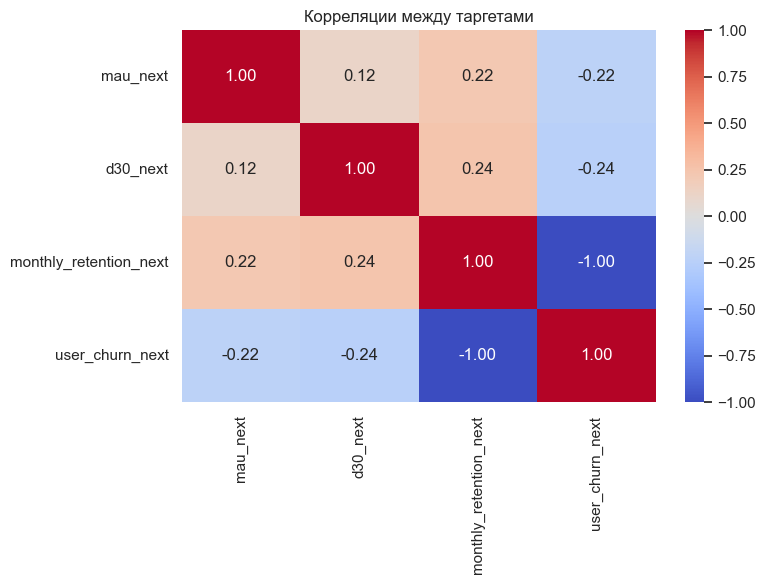

In [36]:
target_cols = ['mau_next', 'd30_next', 'monthly_retention_next', 'user_churn_next']

corr_targets = df_lagged[target_cols].corr(method='pearson')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_targets, annot=True, fmt='.2f', cmap='coolwarm', 
            vmin=-1, vmax=1, center=0)
plt.title('Корреляции между таргетами')
plt.tight_layout()
plt.show()

Главный вывод — monthly_retention_next и user_churn_next это одна и та же метрика с корреляцией -1.00. Один из них нужно убрать прямо сейчас. Оставляем monthly_retention_next — он интуитивнее для интерпретации.

In [40]:
target_cols = ['mau_next', 'd30_next', 'monthly_retention_next']

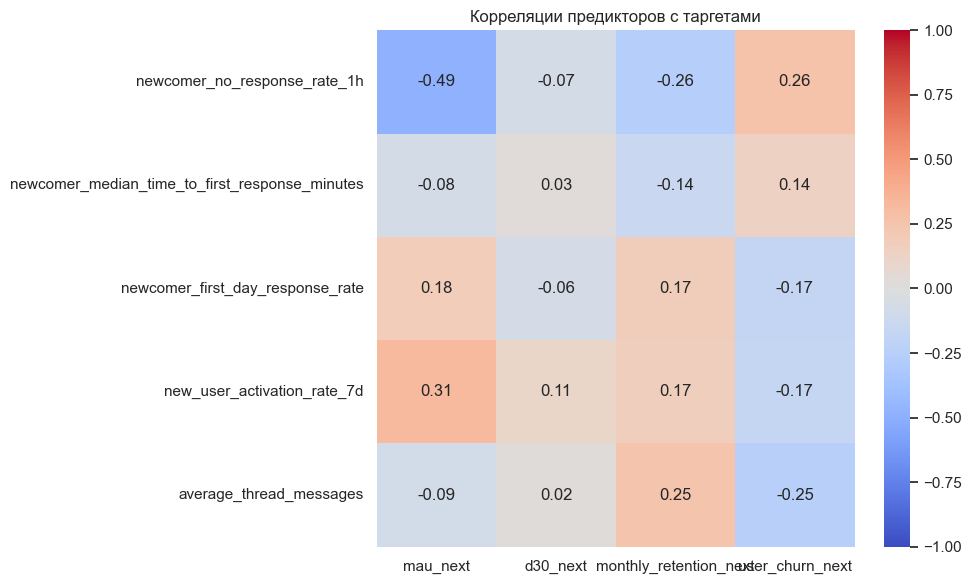

In [37]:
predictor_cols = [
    'newcomer_no_response_rate_1h',
    'newcomer_median_time_to_first_response_minutes',
    'newcomer_first_day_response_rate',
    'new_user_activation_rate_7d',
    'average_thread_messages',
]

corr_pred_target = df_lagged[predictor_cols + target_cols]\
    .corr(method='pearson')\
    .loc[predictor_cols, target_cols]

plt.figure(figsize=(10, 6))
sns.heatmap(corr_pred_target, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0)
plt.title('Корреляции предикторов с таргетами')
plt.tight_layout()
plt.show()

newcomer_median_time_to_first_response_minutesНет сигнала нигде (max 0.14). Кандидат на удаление
Тревожный сигнал: d30_next слабо предсказывается всеми предикторами. Это означает либо нелинейную зависимость, либо отсутствие связи в чат-сообществах.


In [41]:
predictors = [
    'newcomer_no_response_rate_1h',
    'newcomer_first_day_response_rate',
    'new_user_activation_rate_7d',
    'average_thread_messages',
]

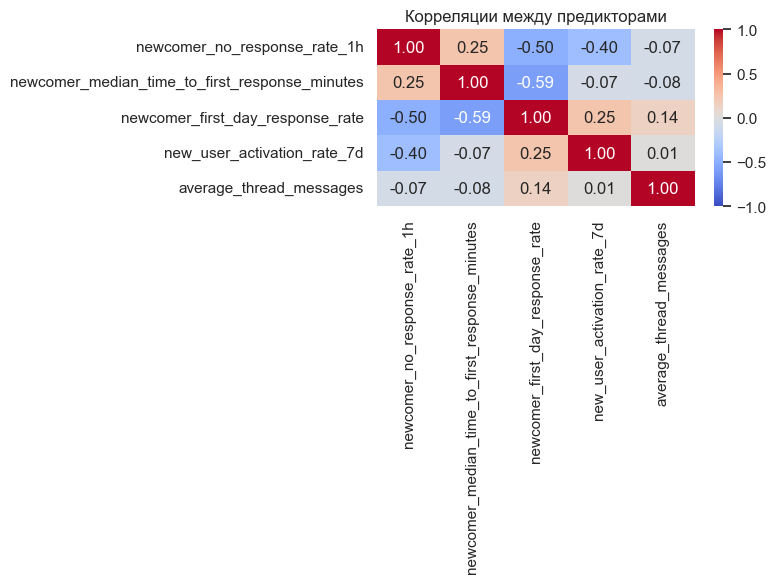

In [39]:
corr_predictors = df_lagged[predictor_cols].corr(method='pearson')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_predictors, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0)
plt.title('Корреляции между предикторами')
plt.tight_layout()
plt.show()

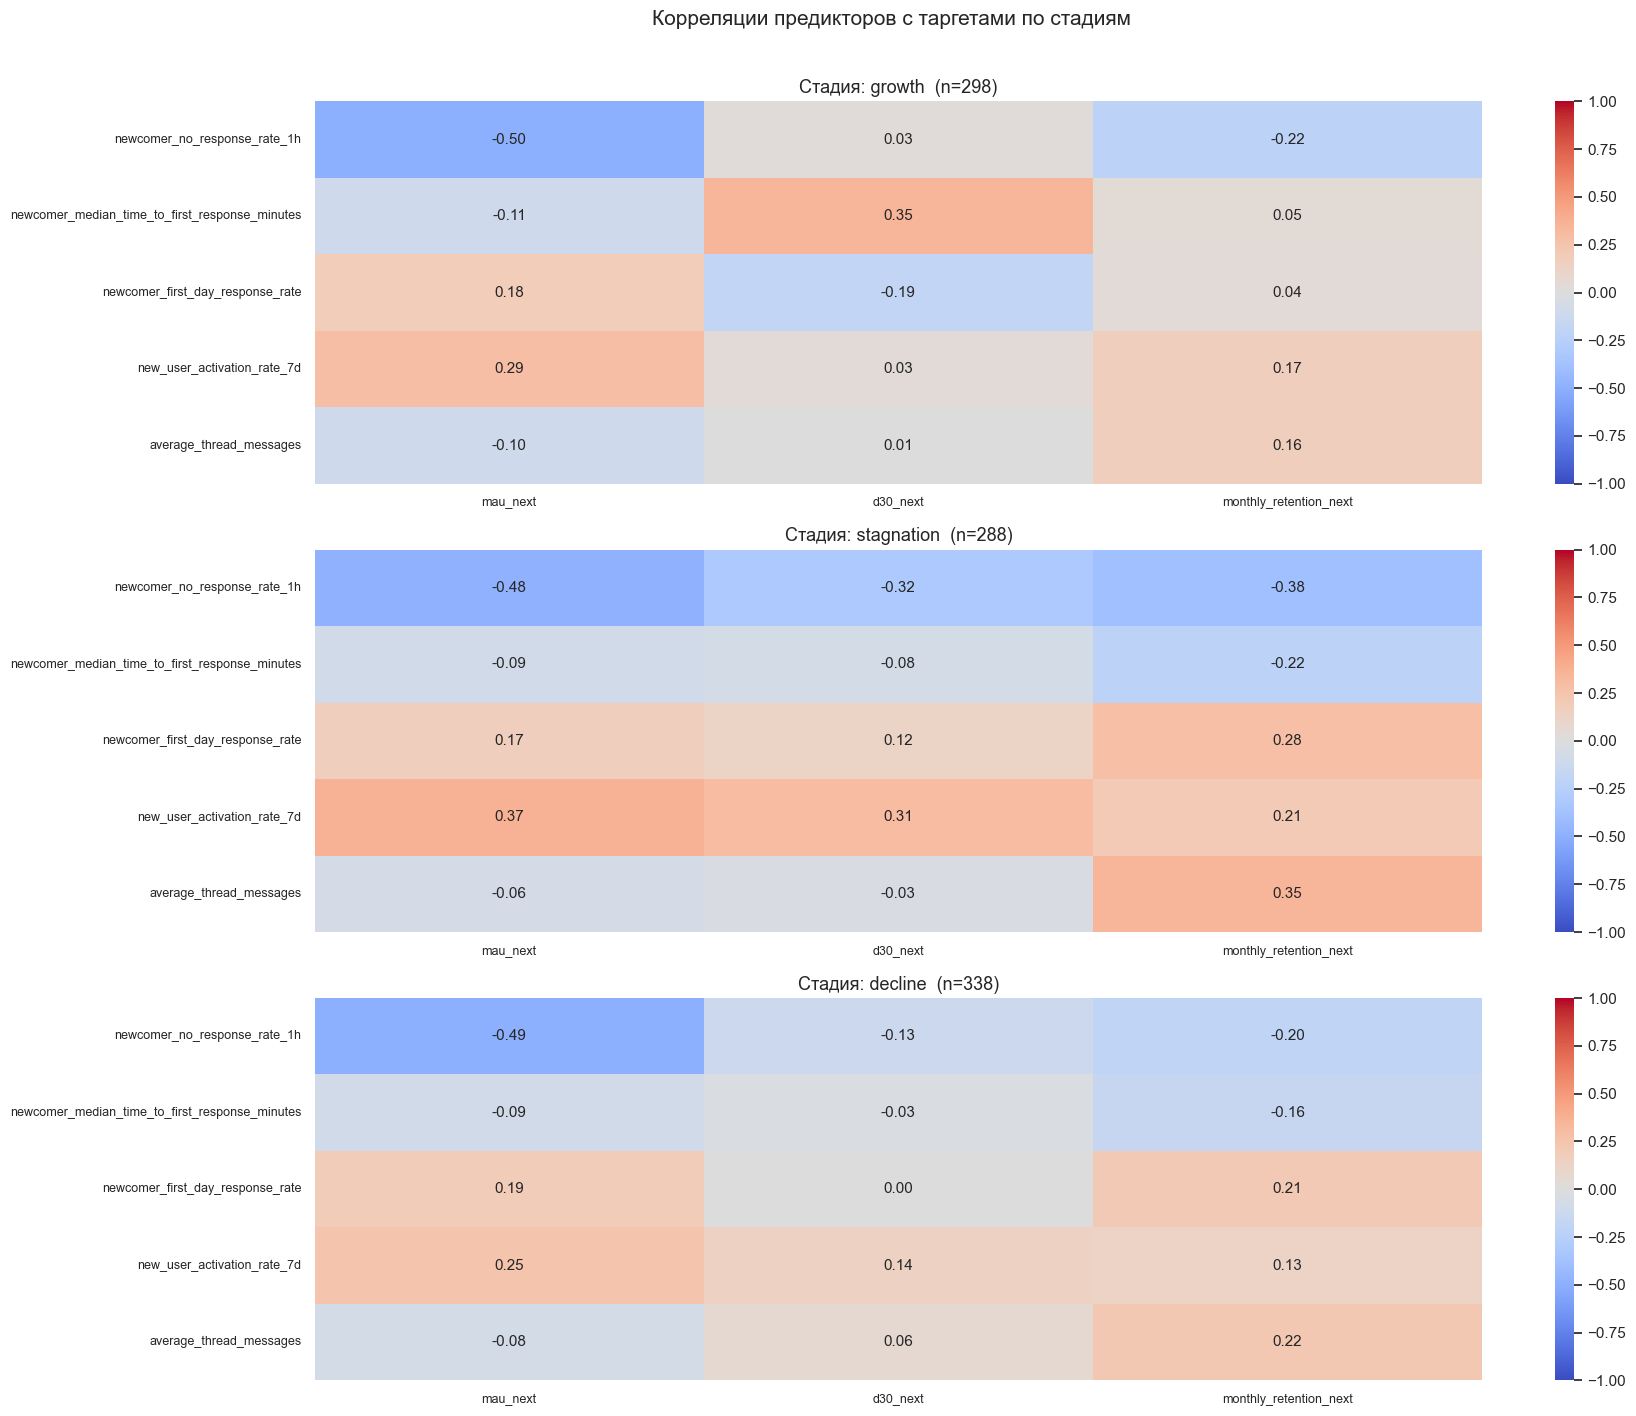

Распределение по стадиям:
stage
decline       338
growth        298
stagnation    288
Name: count, dtype: int64


In [46]:
stages = ['growth', 'stagnation', 'decline']
df_lagged['stage'] = df_lagged['stage'].replace({'mature': 'stagnation'})

fig, axes = plt.subplots(3,1, figsize=(18, 14))
axes = axes.flatten()

for i, stage in enumerate(stages):
    df_stage = df_lagged[df_lagged['stage'] == stage]
    
    corr = df_stage[predictor_cols + target_cols]\
        .corr(method='pearson')\
        .loc[predictor_cols, target_cols]
    
    n = len(df_stage)
    
    sns.heatmap(
        corr, 
        annot=True, 
        fmt='.2f', 
        cmap='coolwarm',
        vmin=-1, vmax=1, center=0,
        ax=axes[i],
        annot_kws={'size': 11}
    )
    axes[i].set_title(f'Стадия: {stage}  (n={n})', fontsize=13)
    axes[i].tick_params(axis='x', labelsize=9)
    axes[i].tick_params(axis='y', labelsize=9)

plt.suptitle('Корреляции предикторов с таргетами по стадиям', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

# Дополнительно — размер каждой стадии
print("Распределение по стадиям:")
print(df_lagged['stage'].value_counts())

Ключевые находки по стадиям
newcomer_no_response_rate_1h — стабильно сильный предиктор MAU везде:
Стадия→ mau_next→ monthly_retention_nextgrowth-0.50-0.22stagnation-0.46-0.39decline-0.49-0.20
Это самый надёжный рычаг во всех стадиях.
new_user_activation_rate_7d — усиливается на стагнации:
Стадия→ mau_next→ d30_nextgrowth0.290.03stagnation0.380.32decline0.250.14
На стагнации этот предиктор влияет сразу на все три таргета — на этой стадии работа с активацией новичков даёт максимальный эффект.
average_thread_messages — влияет только на retention, не на MAU:
Стадия→ monthly_retention_nextgrowth0.16stagnation0.34decline0.22
newcomer_median_time_to_first_response_minutes — неоднозначный. В growth даёт неожиданный положительный знак на d30 (0.35) — это контринтуитивно и скорее всего confounding. Убираем.

In [47]:
predictor_cols = [
    'newcomer_no_response_rate_1h',
    'newcomer_first_day_response_rate',
    'new_user_activation_rate_7d',
    'average_thread_messages',
]

target_cols = ['mau_next', 'd30_next', 'monthly_retention_next']

In [48]:
# Применяем ту же подготовку к df_qa
df_qa_sorted = df_qa.sort_values(['community_id', 'month']).copy()

# Лаговая структура
for target in ['mau', 'd30', 'monthly_retention', 'user_churn']:
    df_qa_sorted[f'{target}_next'] = df_qa_sorted.groupby('community_id')[target].shift(-1)

# Объединяем mature со stagnation
df_qa_sorted['stage_merged'] = df_qa_sorted['stage'].replace({'mature': 'stagnation'})

# Убираем последний месяц каждого сообщества
df_qa_lagged = df_qa_sorted[df_qa_sorted['mau_next'].notna()].copy()

# average_thread_messages: нет тредов = 0
df_qa_lagged['average_thread_messages'] = \
    df_qa_lagged['average_thread_messages'].fillna(0)

# Флаг наличия новичков
df_qa_lagged['has_newcomers'] = \
    df_qa_lagged['newcomer_first_day_response_rate'].notna().astype(int)

print(f"Строк: {len(df_qa_lagged)}")
print(f"\nРаспределение по стадиям:")
print(df_qa_lagged['stage_merged'].value_counts())
print(f"\nПропуски в предикторах:")
print(df_qa_lagged[predictor_cols].isna().sum())

Строк: 4285

Распределение по стадиям:
stage_merged
stagnation    1718
decline       1398
growth        1169
Name: count, dtype: int64

Пропуски в предикторах:
newcomer_no_response_rate_1h        101
newcomer_first_day_response_rate    101
new_user_activation_rate_7d         101
average_thread_messages               0
dtype: int64


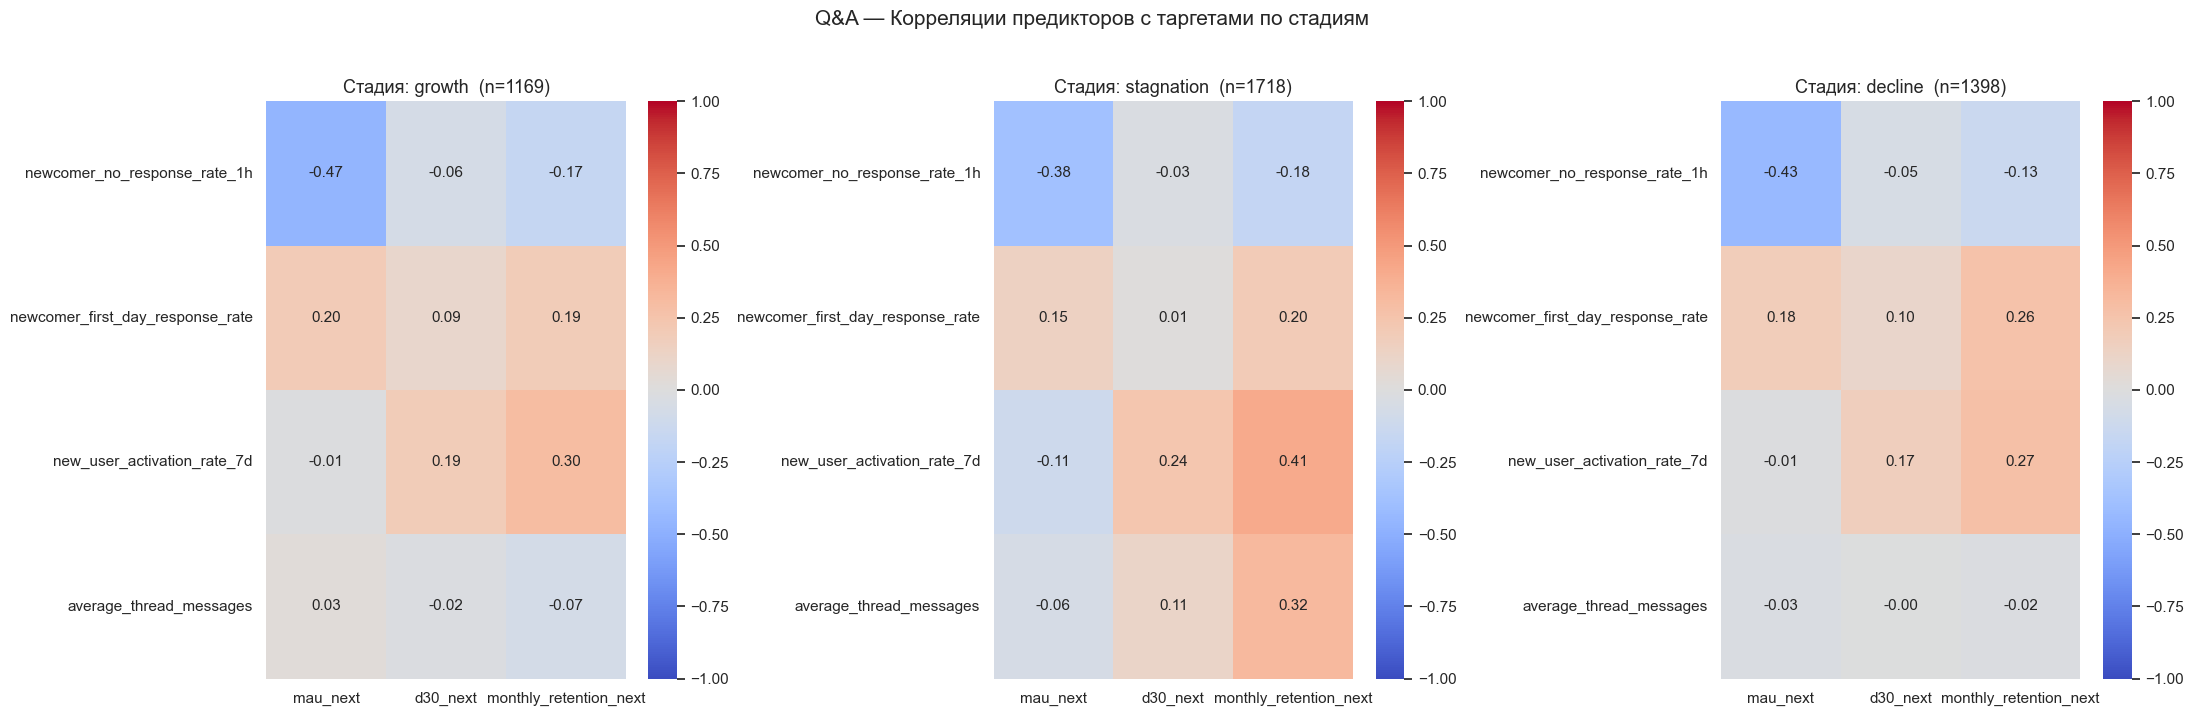

In [49]:
# Q&A специфичные предикторы — добавляем форумные метрики если есть
qa_predictor_cols = [
    'newcomer_no_response_rate_1h',
    'newcomer_first_day_response_rate',
    'new_user_activation_rate_7d',
    'average_thread_messages',
]

target_cols = ['mau_next', 'd30_next', 'monthly_retention_next']
stages = ['growth', 'stagnation', 'decline']

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for i, stage in enumerate(stages):
    df_stage = df_qa_lagged[df_qa_lagged['stage_merged'] == stage]
    
    corr = df_stage[qa_predictor_cols + target_cols]\
        .corr(method='pearson')\
        .loc[qa_predictor_cols, target_cols]
    
    n = len(df_stage)
    
    sns.heatmap(
        corr,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        vmin=-1, vmax=1, center=0,
        ax=axes[i],
        annot_kws={'size': 11}
    )
    axes[i].set_title(f'Стадия: {stage}  (n={n})', fontsize=13)

plt.suptitle('Q&A — Корреляции предикторов с таргетами по стадиям', 
             fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [50]:
# Разные таргеты по приоритету

# Chat — activation влияет на MAU
chat_priority = {
    'mau_next':               ['newcomer_no_response_rate_1h', 
                               'new_user_activation_rate_7d',
                               'newcomer_first_day_response_rate'],
    'monthly_retention_next': ['newcomer_no_response_rate_1h',
                               'average_thread_messages',
                               'newcomer_first_day_response_rate'],
}

# Q&A — activation влияет на retention
qa_priority = {
    'mau_next':               ['newcomer_no_response_rate_1h',
                               'newcomer_first_day_response_rate'],
    'monthly_retention_next': ['new_user_activation_rate_7d',
                               'newcomer_no_response_rate_1h',
                               'average_thread_messages'],
}

In [51]:
target_cols    = ['mau_next', 'monthly_retention_next']

predictor_cols = [
    'newcomer_no_response_rate_1h',
    'newcomer_first_day_response_rate',
    'new_user_activation_rate_7d',
    'average_thread_messages',
]

In [54]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
import pandas as pd
import numpy as np

results = []

df_chat_lagged=df_lagged

for community_type, df_type in [('chat', df_chat_lagged), ('qa', df_qa_lagged)]:
    for stage in ['growth', 'stagnation', 'decline']:
        df_stage = df_type[df_type['stage'] == stage].copy()
        df_stage = df_stage.dropna(subset=predictor_cols + target_cols)
        
        if len(df_stage) < 30:
            print(f"Пропускаем {community_type}/{stage} — мало данных ({len(df_stage)})")
            continue
        
        X = df_stage[predictor_cols]
        
        for target in target_cols:
            y = df_stage[target]
            
            pipe = Pipeline([
                ('scaler', StandardScaler()),
                ('model',  Ridge(alpha=1.0))
            ])
            pipe.fit(X, y)
            
            y_pred = pipe.predict(X)
            r2    = r2_score(y, y_pred)
            coefs = dict(zip(predictor_cols, pipe['model'].coef_))
            
            results.append({
                'type':    community_type,
                'stage':   stage,
                'target':  target,
                'r2':      round(r2, 3),
                **{f'coef_{k}': round(v, 4) for k, v in coefs.items()}
            })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

type      stage                 target    r2  coef_newcomer_no_response_rate_1h  coef_newcomer_first_day_response_rate  coef_new_user_activation_rate_7d  coef_average_thread_messages
chat     growth               mau_next 0.292                          -388.8346                               -52.2446                           53.6276                     -143.7059
chat     growth monthly_retention_next 0.083                            -4.4958                                -2.2804                            1.5258                        3.0919
chat stagnation               mau_next 0.303                          -356.1178                               -85.1923                          180.8309                      -92.5507
chat stagnation monthly_retention_next 0.253                            -6.7482                                 1.4554                            2.6195                        6.7184
chat    decline               mau_next 0.266                          -257.6269      

In [59]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def check_vif(df, predictors):
    X = df[predictors].dropna()
    vif_data = pd.DataFrame({
        'feature': predictors,
        'VIF': [variance_inflation_factor(X.values, i) 
                for i in range(len(predictors))]
    })
    return vif_data.sort_values('VIF', ascending=False)

# Проверяем по каждому типу
print("=== CHAT ===")
print(check_vif(df_chat_lagged, predictor_cols))

print("\n=== Q&A ===")
print(check_vif(df_qa_lagged, predictor_cols))

=== CHAT ===
                            feature       VIF
1  newcomer_first_day_response_rate  6.639558
2       new_user_activation_rate_7d  4.252900
0      newcomer_no_response_rate_1h  1.876699
3           average_thread_messages  1.769662

=== Q&A ===
                            feature       VIF
1  newcomer_first_day_response_rate  9.019082
2       new_user_activation_rate_7d  8.615249
0      newcomer_no_response_rate_1h  1.298068
3           average_thread_messages  1.025617


In [61]:
predictor_cols_clean = [
    'newcomer_no_response_rate_1h',
    'new_user_activation_rate_7d',
    'average_thread_messages',
]

print("=== CHAT ===")
print(check_vif(df_chat_lagged, predictor_cols_clean))

print("\n=== Q&A ===")
print(check_vif(df_qa_lagged, predictor_cols_clean))

=== CHAT ===
                        feature       VIF
1   new_user_activation_rate_7d  1.623711
2       average_thread_messages  1.539023
0  newcomer_no_response_rate_1h  1.374867

=== Q&A ===
                        feature       VIF
1   new_user_activation_rate_7d  1.256523
0  newcomer_no_response_rate_1h  1.250499
2       average_thread_messages  1.010572


In [63]:
predictor_cols_clean = [
    'newcomer_no_response_rate_1h',
    'new_user_activation_rate_7d',
    'average_thread_messages',
]

results = []

for community_type, df_type in [('chat', df_chat_lagged), ('qa', df_qa_lagged)]:
    for stage in ['growth', 'stagnation', 'decline']:
        df_stage = df_type[df_type['stage'] == stage].copy()
        df_stage = df_stage.dropna(subset=predictor_cols_clean + target_cols)
        
        if len(df_stage) < 30:
            print(f"Пропускаем {community_type}/{stage} — мало данных ({len(df_stage)})")
            continue
        
        X = df_stage[predictor_cols_clean]
        
        for target in target_cols:
            y = df_stage[target]
            
            pipe = Pipeline([
                ('scaler', StandardScaler()),
                ('model',  Ridge(alpha=1.0))
            ])
            pipe.fit(X, y)
            
            y_pred = pipe.predict(X)
            r2    = r2_score(y, y_pred)
            coefs = dict(zip(predictor_cols_clean, pipe['model'].coef_))
            
            results.append({
                'type':   community_type,
                'stage':  stage,
                'target': target,
                'r2':     round(r2, 3),
                **{f'coef_{k}': round(v, 4) for k, v in coefs.items()}
            })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

type      stage                 target    r2  coef_newcomer_no_response_rate_1h  coef_new_user_activation_rate_7d  coef_average_thread_messages
chat     growth               mau_next 0.288                          -360.7474                           57.7614                     -146.9868
chat     growth monthly_retention_next 0.074                            -3.2698                            1.7062                        2.9487
chat stagnation               mau_next 0.294                          -316.5506                          170.9260                     -101.7879
chat stagnation monthly_retention_next 0.250                            -7.4241                            2.7887                        6.8762
chat    decline               mau_next 0.264                          -243.8535                           51.5069                      -55.5953
chat    decline monthly_retention_next 0.088                            -3.3147                            1.2480                       

In [64]:
# Какие предикторы применимы для каких таргетов
recommendation_map = {
    'chat': {
        'mau_next': [
            'newcomer_no_response_rate_1h',   # ✅ отрицательный = правильно
            'new_user_activation_rate_7d',    # ✅ положительный = правильно
            # average_thread_messages — ❌ не используем для MAU
        ],
        'monthly_retention_next': [
            'newcomer_no_response_rate_1h',   # ✅
            'new_user_activation_rate_7d',    # ✅
            'average_thread_messages',        # ✅ положительный = правильно
        ],
    },
    'qa': {
        'mau_next': [
            'newcomer_no_response_rate_1h',   # ✅
            # new_user_activation_rate_7d — ❌ не используем для MAU
            # average_thread_messages — ❌ слабый и отрицательный
        ],
        'monthly_retention_next': [
            'newcomer_no_response_rate_1h',   # ✅
            'new_user_activation_rate_7d',    # ✅ положительный = правильно
            'average_thread_messages',        # ✅ в stagnation
        ],
    },
}

In [66]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd

# ── 1. ОБУЧЕНИЕ МОДЕЛЕЙ ──────────────────────────────────────────────

R2_THRESHOLD = 0.15

predictor_cols_clean = [
    'newcomer_no_response_rate_1h',
    'new_user_activation_rate_7d',
    'average_thread_messages',
]

target_cols = ['mau_next', 'monthly_retention_next']

recommendation_map = {
    'chat': {
        'mau_next':               ['newcomer_no_response_rate_1h', 
                                   'new_user_activation_rate_7d'],
        'monthly_retention_next': ['newcomer_no_response_rate_1h',
                                   'new_user_activation_rate_7d',
                                   'average_thread_messages'],
    },
    'qa': {
        'mau_next':               ['newcomer_no_response_rate_1h'],
        'monthly_retention_next': ['newcomer_no_response_rate_1h',
                                   'new_user_activation_rate_7d',
                                   'average_thread_messages'],
    },
}

# Направление улучшения каждого предиктора
predictor_direction = {
    'newcomer_no_response_rate_1h': 'decrease',  # хотим снизить
    'new_user_activation_rate_7d':  'increase',  # хотим повысить
    'average_thread_messages':      'increase',  # хотим повысить
}

# Человекочитаемые названия
predictor_labels = {
    'newcomer_no_response_rate_1h': 'Доля новичков без ответа за 1 час',
    'new_user_activation_rate_7d':  'Активация новичков за 7 дней',
    'average_thread_messages':      'Среднее сообщений в треде',
}

target_labels = {
    'mau_next':               'MAU (следующий месяц)',
    'monthly_retention_next': 'Retention (следующий месяц)',
}

models    = {}  # (type, stage, target) → pipeline
r2_scores = {}  # (type, stage, target) → r2
scalers   = {}  # (type, stage) → fitted scaler (для расчёта std)

for community_type, df_type in [('chat', df_chat_lagged), ('qa', df_qa_lagged)]:
    for stage in ['growth', 'stagnation', 'decline']:
        df_stage = df_type[
            df_type['stage'] == stage
        ].dropna(subset=predictor_cols_clean + target_cols).copy()

        if len(df_stage) < 30:
            continue

        X = df_stage[predictor_cols_clean]

        # Сохраняем scaler для расчёта std предикторов
        sc = StandardScaler().fit(X)
        scalers[(community_type, stage)] = sc

        for target in target_cols:
            y = df_stage[target]

            pipe = Pipeline([
                ('scaler', StandardScaler()),
                ('model',  Ridge(alpha=1.0))
            ])
            pipe.fit(X, y)

            r2 = r2_score(y, pipe.predict(X))
            models[(community_type, stage, target)]    = pipe
            r2_scores[(community_type, stage, target)] = round(r2, 3)

print("Модели обучены:")
for key, r2 in r2_scores.items():
    flag = "✅" if r2 >= R2_THRESHOLD else "❌ низкий R²"
    print(f"  {key[0]:6} / {key[1]:12} / {key[2]:25} r²={r2} {flag}")

Модели обучены:
  chat   / growth       / mau_next                  r²=0.288 ✅
  chat   / growth       / monthly_retention_next    r²=0.074 ❌ низкий R²
  chat   / stagnation   / mau_next                  r²=0.294 ✅
  chat   / stagnation   / monthly_retention_next    r²=0.25 ✅
  chat   / decline      / mau_next                  r²=0.264 ✅
  chat   / decline      / monthly_retention_next    r²=0.088 ❌ низкий R²
  qa     / growth       / mau_next                  r²=0.236 ✅
  qa     / growth       / monthly_retention_next    r²=0.104 ❌ низкий R²
  qa     / stagnation   / mau_next                  r²=0.218 ✅
  qa     / stagnation   / monthly_retention_next    r²=0.31 ✅
  qa     / decline      / mau_next                  r²=0.2 ✅
  qa     / decline      / monthly_retention_next    r²=0.08 ❌ низкий R²


In [67]:
# ── 2. БЕНЧМАРКИ ────────────────────────────────────────────────────

benchmarks = {}  # (type, stage, predictor) → {'p25', 'p50', 'p75', 'mean'}

for community_type, df_type in [('chat', df_chat_lagged), ('qa', df_qa_lagged)]:
    for stage in ['growth', 'stagnation', 'decline']:
        df_stage = df_type[
            df_type['stage'] == stage
        ].dropna(subset=predictor_cols_clean)

        for predictor in predictor_cols_clean:
            vals = df_stage[predictor]
            benchmarks[(community_type, stage, predictor)] = {
                'p25':  round(vals.quantile(0.25), 4),
                'p50':  round(vals.quantile(0.50), 4),
                'p75':  round(vals.quantile(0.75), 4),
                'mean': round(vals.mean(), 4),
            }

print("Бенчмарки рассчитаны")

Бенчмарки рассчитаны


In [73]:
from scipy import stats

def get_current_percentile(current_val, community_type, stage, predictor):
    df_type  = df_chat_lagged if community_type == 'chat' else df_qa_lagged
    df_stage = df_type[df_type['stage'] == stage][predictor].dropna()
    return int(stats.percentileofscore(df_stage, current_val))


def get_recommendations(community_id, community_type, stage,
                        current_values: dict, top_n: int = 2):
    recommendations = []

    for target in target_cols:
        key = (community_type, stage, target)

        if r2_scores.get(key, 0) < R2_THRESHOLD:
            continue

        pipe             = models[key]
        valid_predictors = recommendation_map[community_type][target]
        coefs            = dict(zip(predictor_cols_clean, pipe['model'].coef_))
        sc               = scalers[(community_type, stage)]
        stds             = dict(zip(predictor_cols_clean, sc.scale_))

        for predictor in valid_predictors:
            if predictor not in current_values:
                continue

            current_val = current_values[predictor]
            bench       = benchmarks[(community_type, stage, predictor)]
            direction   = predictor_direction[predictor]

            target_val = bench['p25'] if direction == 'decrease' \
                         else bench['p75']

            if direction == 'decrease' and current_val <= target_val:
                continue
            if direction == 'increase' and current_val >= target_val:
                continue

            delta  = target_val - current_val
            std    = stds[predictor]
            effect = coefs[predictor] * (delta / std)

            recommendations.append({
                'target':       target,
                'predictor':    predictor,
                'current_val':  round(current_val, 4),
                'target_val':   round(target_val, 4),
                'delta':        round(delta, 4),
                'effect':       round(effect, 2),
                'r2':           r2_scores[key],
                'percentile':   '25й' if direction == 'decrease' else '75й',
            })

    if not recommendations:
        return f"Нет рекомендаций для {community_id} — все метрики уже на целевом уровне"

    recommendations = sorted(recommendations,
                             key=lambda x: abs(x['effect']),
                             reverse=True)

    output = [f"📊 Рекомендации для {community_id} "
              f"(тип: {community_type}, стадия: {stage})\n"]

    for i, rec in enumerate(recommendations[:top_n], 1):
        direction_word = "снизить" \
            if predictor_direction[rec['predictor']] == 'decrease' \
            else "повысить"
        effect_word  = "+" if rec['effect'] > 0 else ""
        units        = "пользователей" if 'mau' in rec['target'] else "п.п."
        current_pct  = get_current_percentile(
            rec['current_val'], community_type, stage, rec['predictor']
        )

        output.append(
            f"{i}. {direction_word.upper()} «{predictor_labels[rec['predictor']]}»\n"
            f"   Сейчас: {rec['current_val']} ({current_pct}й перцентиль) → "
            f"Цель: {rec['target_val']} ({rec['percentile']} перцентиль)\n"
            f"   Эффект на {target_labels[rec['target']]}: "
            f"{effect_word}{rec['effect']} {units}\n"
            f"   (R²={rec['r2']})\n"
        )

    return "\n".join(output)

In [1]:
test_id    = 'acer'       # название сообщества
test_month = '2023-09'    # конкретный месяц

def get_current_values(community_id, df, month=None):
    df_comm = df[df['community_id'] == community_id].sort_values('month')
    
    if month:
        row = df_comm[df_comm['month'].astype(str) == month]
        if len(row) == 0:
            print(f"Месяц {month} не найден, берём последний")
            row = df_comm.iloc[[-1]]
    else:
        row = df_comm.iloc[[-1]]
    
    last_row = row.iloc[-1]
    return {p: last_row[p] for p in predictor_cols_clean 
            if pd.notna(last_row[p])}

test_type  = 'chat'
test_stage = df_chat_lagged[
    df_chat_lagged['community_id'] == test_id
].sort_values('month').iloc[-1]['stage']

current_vals = get_current_values(test_id, df_chat_lagged, month=test_month)

print(get_recommendations(test_id, test_type, test_stage, current_vals)) 

NameError: name 'df_chat_lagged' is not defined